In [ ]:
from FeatureDetectorMatcher import FeatureDetectorMatcher

import cv2 
import numpy as np
from utils import resize_image

/home/ituarc/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/ituarc/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/ituarc/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/ituarc/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


In [2]:
import numpy as np

In [19]:
traj_log = np.load('/home/ituarc/Documents/GitHub/FeatureMatching-PythonCODE/logs/20251226_215758/traj/PF_pos_list.npy')


traj_log.shape

(2856, 3)

In [20]:
traj_log

array([[-2.1417744e+00, -7.9259712e-01, -3.0344611e-02],
       [-2.1483891e+00, -7.8954291e-01, -3.7506282e-02],
       [-2.1471238e+00, -7.8699315e-01, -4.6490207e-02],
       ...,
       [ 2.3385895e+01, -5.2696606e+01, -6.5191040e+01],
       [ 2.3414358e+01, -5.2704380e+01, -6.5190544e+01],
       [ 2.3437145e+01, -5.2714806e+01, -6.5190086e+01]], dtype=float32)

In [4]:
traj_log = traj_log - traj_log[0]

In [5]:
traj_log[0]

array([0., 0., 0.], dtype=float32)

In [107]:
traj_log_d = traj_log.copy()
traj_log_d = np.hstack((traj_log_d, np.array([1])))

In [108]:
traj_log_d[1:] = traj_log

In [109]:
a = traj_log - traj_log_d[0:-1]

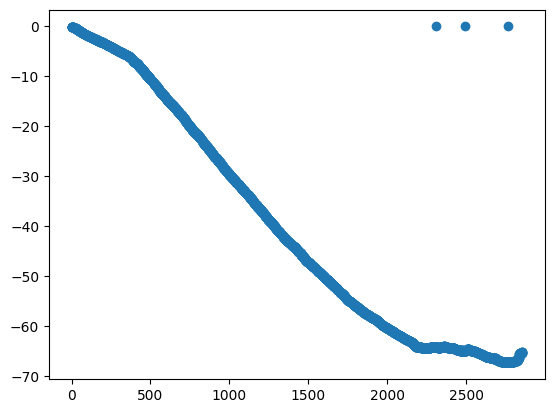

In [28]:
#scattter plot of a
import matplotlib.pyplot as plt
import numpy as np

a = traj_log[:, 2]

plt.scatter(np.arange(len(a)), a)
plt.show()


In [18]:
traj_log.max()

1766585832.3531036

In [ ]:
traj_log_d

detector_opt = {'type': 'XFEAT'}
hFeatureDM = FeatureDetectorMatcher(detector_opt=detector_opt)

In [5]:
def create_nonblack_mask(image: np.ndarray, threshold: int = 0) -> np.ndarray:
    """
    Create a binary mask from a grayscale image where non-black pixels are marked as 1
    and black pixels are marked as 0.
    
    Parameters
    ----------
    image : np.ndarray
        Input grayscale image (H, W) or color image (H, W, C).
        For color images, a pixel is considered black only if ALL channels are <= threshold.
    threshold : int, optional
        Threshold value to determine black pixels. Pixels with intensity <= threshold
        are considered black. Default is 0 (only pure black pixels).
        
    Returns
    -------
    mask : np.ndarray, dtype=uint8
        Binary mask of same height and width as input image.
        Values: 0 = black pixel, 1 = non-black pixel.
        Can be used with cv2 functions by multiplying with 255.
        
    Examples
    --------
    >>> # Create mask for pure black pixels
    >>> mask = create_nonblack_mask(gray_image)
    >>> 
    >>> # Create mask with tolerance (pixels <= 10 are considered black)
    >>> mask = create_nonblack_mask(gray_image, threshold=10)
    >>> 
    >>> # Use with cv2 (needs 0/255 values)
    >>> mask_cv2 = mask * 255
    >>> masked_image = cv2.bitwise_and(image, image, mask=mask_cv2)
    """
    if image.ndim == 2:
        # Grayscale image: simple threshold
        mask = (image > threshold).astype(np.uint8)
    
    elif image.ndim == 3:
        # Color image: pixel is non-black if ANY channel > threshold
        mask = np.any(image > threshold, axis=2).astype(np.uint8)
    
    else:
        raise ValueError(f"Input image must be 2D (grayscale) or 3D (color), got {image.ndim}D")
    
    return mask

In [43]:
im1 = cv2.imread('PartFrame_1765565704.7419.png', cv2.IMREAD_GRAYSCALE)
# im2 = cv2.imread('UAVFrame_1765565704.7419.png', cv2.IMREAD_GRAYSCALE)
im2 = cv2.imread('UAVFrame_1765565734.8059.png', cv2.IMREAD_GRAYSCALE)



# im1 = resize_image(im1, (243, 243))
# im2 = resize_image(im2, (243, 243))

mask = create_nonblack_mask(im1)

# znccMatch(patches, template, mask)

# im1 = im1[30:200, 40:380]
# im2 = im2[30:200, 40:380]
# mask = mask[30:200, 40:380]

patches = np.stack([im1, im2], axis=0) 

ValueError: all input arrays must have the same shape

In [39]:
im1.shape

(170, 340)

In [37]:
# im1 = 

cv2.imshow('Mask', im2[30:200, 40:380])  # Scale mask for visualization
cv2.waitKey(0)
cv2.destroyAllWindows()


In [40]:
hFeatureDM.znccMatch(patches, im1, mask)

array([1.       , 0.1497318], dtype=float32)

In [41]:
zncc_batch_patches(patches, im1)

array([1.0000006 , 0.14973168], dtype=float32)

In [42]:
masked_zncc_batch_patches(patches, im1, mask)

array([1.0000006 , 0.14973253], dtype=float32)

In [19]:
a = np.concatenate((im1,im2), axis=1)
a.shape

(322, 950)

In [14]:
def zncc_batch_patches(patches: np.ndarray, template: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Unmasked ZNCC (baseline). patches: (N,h,w), template: (h,w) -> (N,)"""
    P = patches.astype(np.float32).reshape(patches.shape[0], -1)
    T = template.astype(np.float32).ravel()

    T0 = T - T.mean()
    denom_T = np.sqrt(np.dot(T0, T0)) + eps

    P0 = P - P.mean(axis=1, keepdims=True)
    num = P0 @ T0
    denom = (np.linalg.norm(P0, axis=1) * denom_T) + eps
    return num / denom

In [15]:
def masked_zncc_batch_patches(patches: np.ndarray,
                             template: np.ndarray,
                             mask: np.ndarray,
                             eps: float = 1e-12) -> np.ndarray:
    """
    Masked ZNCC (ignores mask==0 pixels).
    patches : (N,h,w) satellite patches (particles)
    template: (h,w) UAV template (orthoprojected)
    mask    : (h,w) 1=valid, 0=invalid (black region)
    returns : (N,) masked ZNCC scores
    """
    P = patches.astype(np.float32).reshape(patches.shape[0], -1)   # (N,M)
    T = template.astype(np.float32).ravel()                        # (M,)
    M = mask.astype(np.float32).ravel()                            # (M,)

    w = M.sum()
    if w < 1:
        raise ValueError("Mask has no valid pixels (sum(mask)==0).")

    w = w + eps

    # Weighted (masked) zero-mean template
    mu_T = (M * T).sum() / w
    T0 = (T - mu_T) * M
    denom_T = np.sqrt((T0 * T0).sum()) + eps

    # Per-patch weighted mean/variance over valid pixels only
    S  = (P * M).sum(axis=1)              # sum M*I
    S2 = ((P * P) * M).sum(axis=1)        # sum M*I^2
    var = S2 - (S * S) / w                # sum M*(I - mu_I)^2
    var = np.maximum(var, eps)
    denom_I = np.sqrt(var)

    # Numerator becomes a dot product / correlation with T0
    num = P @ T0

    return num / (denom_I * denom_T)